<a href="https://colab.research.google.com/github/chlaitha/real-world-industry-projects/blob/main/Predictive_Modeling_of_Hotel_Cancellations_%26_Revenue_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Predictive Modeling of Hotel Cancellations & Revenue Optimization
**Introduction**: This notebook demonstrates an end-to-end data science pipeline to analyze, quantify, and predict hotel booking cancellations using the Hotel Booking Demand dataset.

# 1. Project Overview & Environment Setup

### Context & Business Problem
High cancellation rates create operational bottlenecks for hotels—impacting staffing, food and beverage forecasting, and dynamic pricing strategies. Predicting which reservations are at risk of cancellation allows hotel operations to enforce selective deposit rules, shorten cancellation windows, or manage targeted overbooking strategies.

### Project Steps
1. **Data Cleaning & Feature Engineering**: Handle missing values, filter operational anomalies, and construct total stay/revenue features.
2. **Exploratory Data Analysis (EDA)**: Identify key drivers of cancellation (lead time, deposit types, special requests).
3. **Financial Risk & Revenue Analysis**: Quantify realized vs. lost potential revenue across customer segments.
4. **Predictive Modeling**: Train a LightGBM classification model to score cancellation risk at booking time.

In [16]:
# Import libraries amd suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Imports and Global Visualization Settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from lightgbm import LGBMClassifier

# Configure matplotlib formatting for clean portfolio displays
plt.rcParams['font.size'] = 8
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7

# 2. Data Cleaning & Feature Engineering

In this step, we:
* Fill missing values in demographic and agency columns.
* Filter out invalid bookings (e.g., zero total guests or negative Average Daily Rates).
* Engineer aggregate features: `total_nights`, `total_guests`, `booking_revenue`, and binary flags (`is_family`, `has_parking`).

In [17]:
# Mount Google drive & load data
from google.colab import drive
drive.mount('/content/gdrive')

df = pd.read_csv('/content/gdrive/My Drive/Notebooks/hotel.csv')

# 1. Missing Value Imputation
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(-1).astype(int)
df['company'] = df['company'].fillna(-1).astype(int)

# 2. Data Cleaning Rules
df = df[(df['adults'] + df['children'] + df['babies']) > 0]
df = df[df['adr'] >= 0]

# 3. Feature Engineering
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['is_family'] = ((df['children'] > 0) | (df['babies'] > 0)).astype(int)
df['has_parking'] = (df['required_car_parking_spaces'] > 0).astype(int)
df['booking_revenue'] = df['adr'] * df['total_nights']

print(f"Dataset shape after cleaning: {df.shape}")
df.head()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Dataset shape after cleaning: (119209, 37)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,is_family,has_parking,booking_revenue
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,0,0,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0.0,0,0,Check-Out,2015-07-01,0,2.0,0,0,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,0,0,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,75.0,0,0,Check-Out,2015-07-02,1,1.0,0,0,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,98.0,0,1,Check-Out,2015-07-03,2,2.0,0,0,196.0


# 3. Exploratory Data Analysis (EDA)

We explore key booking behavioral patterns:
* **Lead Time**: How far in advance guests book vs. their cancellation rates.
* **Deposit Types**: The cancellation rate associated with `No Deposit`, `Non Refundable`, and `Refundable`.
* **ADR Distribution**: Pricing variance across Resort and City Hotels by cancellation status.
* **Special Requests**: Whether customer engagement reduces cancellation likelihood.

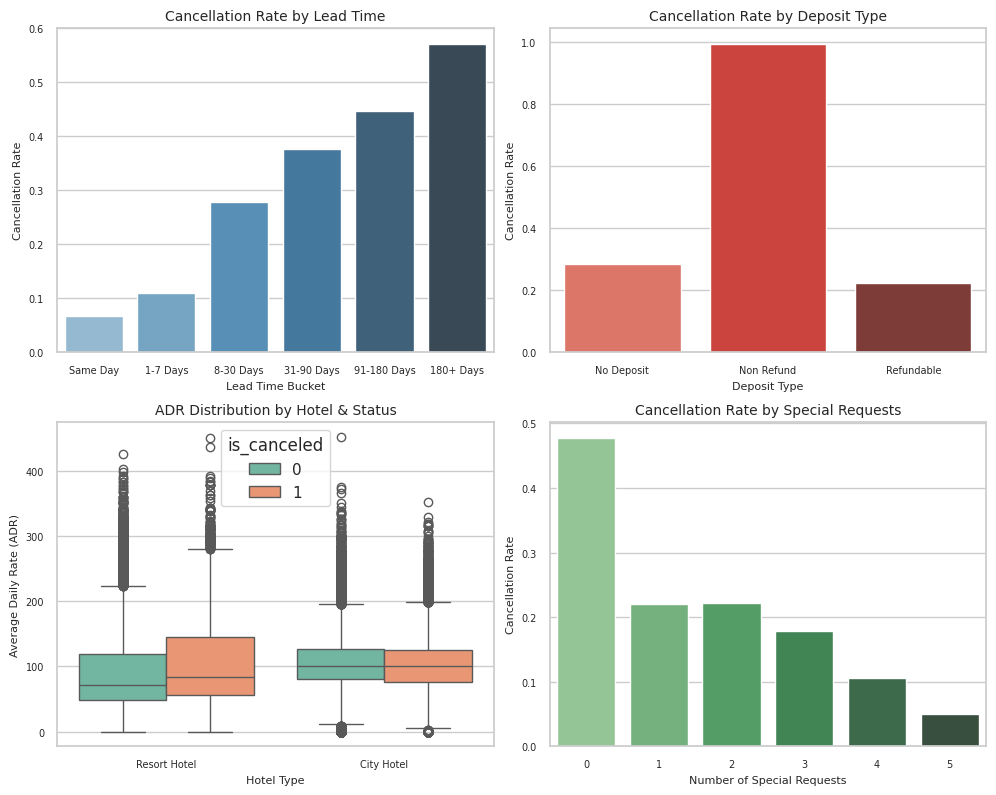

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# Plot 1: Cancellation Rate by Lead Time Bucket
df['lead_time_bucket'] = pd.cut(
    df['lead_time'],
    bins=[-1, 0, 7, 30, 90, 180, 737],
    labels=['Same Day', '1-7 Days', '8-30 Days', '31-90 Days', '91-180 Days', '180+ Days']
)
lead_time_cancel = df.groupby('lead_time_bucket', observed=False)['is_canceled'].mean().reset_index()

sns.barplot(
    data=lead_time_cancel, x='lead_time_bucket', y='is_canceled',
    ax=axes[0, 0], palette='Blues_d'
)
axes[0, 0].set_title('Cancellation Rate by Lead Time')
axes[0, 0].set_xlabel('Lead Time Bucket')
axes[0, 0].set_ylabel('Cancellation Rate')
axes[0, 0].set_ylim(0, 0.6)

# Plot 2: Deposit Type vs Cancellation Rate
deposit_cancel = df.groupby('deposit_type')['is_canceled'].mean().reset_index()
sns.barplot(
    data=deposit_cancel, x='deposit_type', y='is_canceled',
    ax=axes[0, 1], palette='Reds_d'
)
axes[0, 1].set_title('Cancellation Rate by Deposit Type')
axes[0, 1].set_xlabel('Deposit Type')
axes[0, 1].set_ylabel('Cancellation Rate')

# Plot 3: ADR Distribution by Hotel Type & Cancellation Status
sns.boxplot(
    data=df[df['adr'] < 500], x='hotel', y='adr', hue='is_canceled',
    ax=axes[1, 0], palette='Set2'
)
axes[1, 0].set_title('ADR Distribution by Hotel & Status')
axes[1, 0].set_xlabel('Hotel Type')
axes[1, 0].set_ylabel('Average Daily Rate (ADR)')

# Plot 4: Special Requests vs Cancellation
request_cancel = df.groupby('total_of_special_requests')['is_canceled'].mean().reset_index()
sns.barplot(
    data=request_cancel, x='total_of_special_requests', y='is_canceled',
    ax=axes[1, 1], palette='Greens_d'
)
axes[1, 1].set_title('Cancellation Rate by Special Requests')
axes[1, 1].set_xlabel('Number of Special Requests')
axes[1, 1].set_ylabel('Cancellation Rate')

plt.tight_layout()
plt.show()

# 4. Financial & Revenue Exposure Analysis

This step quantifies the financial impact of cancellations by calculating:
* **Realized Revenue**: Revenue earned from fulfilled stays.
* **Lost Revenue**: Potential revenue lost to canceled reservations.
* **Cancellation Rates**: Grouped by property type and deposit structure.

In [19]:
revenue_summary = df.groupby(['hotel', 'deposit_type']).agg(
    total_bookings=('is_canceled', 'count'),
    canceled_bookings=('is_canceled', 'sum'),
    realized_revenue=('booking_revenue', lambda x: x[df.loc[x.index, 'is_canceled'] == 0].sum()),
    lost_revenue=('booking_revenue', lambda x: x[df.loc[x.index, 'is_canceled'] == 1].sum()),
    avg_adr=('adr', 'mean')
).reset_index()

revenue_summary['cancellation_rate_pct'] = (
    revenue_summary['canceled_bookings'] / revenue_summary['total_bookings'] * 100
).round(2)

revenue_summary

,hotel,deposit_type,total_bookings,canceled_bookings,realized_revenue,lost_revenue,avg_adr,cancellation_rate_pct
0,City Hotel,No Deposit,66275,20221,14378535.23,7708165.82,107.901688,30.51
1,City Hotel,Non Refund,12868,12844,5983.02,3166272.84,93.135309,99.81
2,City Hotel,Refundable,20,14,823.75,10621.12,114.977500,70.00
3,Resort Hotel,No Deposit,38185,9448,11562343.72,5394736.10,96.370469,24.74
4,Resort Hotel,Non Refund,1719,1650,11126.85,438064.19,66.224532,95.99
5,Resort Hotel,Refundable,142,22,28163.46,9377.05,70.749507,15.49


# 5. Machine Learning Pipeline (LightGBM)

We train a **LightGBM** classifier to predict cancellation risk (`is_canceled`).

### Methodology:
1. Select features available at the time of reservation to avoid data leakage.
2. Convert categorical features to `category` dtypes for native LightGBM processing.
3. Perform a stratified train/test split ($80/20$).
4. Evaluate using **ROC-AUC** and **Classification Report**.
5. Plot feature importances to identify top predictive signals.

[LightGBM] [Info] Number of positive: 35359, number of negative: 60008
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024567 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1030
[LightGBM] [Info] Number of data points in the train set: 95367, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.370768 -> initscore=-0.528925
[LightGBM] [Info] Start training from score -0.528925
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
ROC-AUC Score: 0.9020

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.94      0.88     15002
           1       0.86      0.65      0.74      8840

    accuracy                           0.83     23842
   macro avg       0.84    

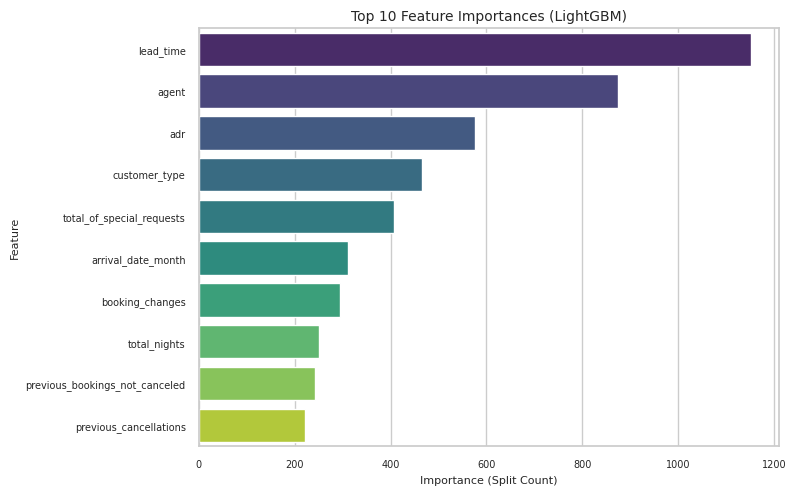

In [20]:
# 1. Feature Selection
feature_cols = [
    'hotel', 'lead_time', 'arrival_date_month', 'stays_in_weekend_nights',
    'stays_in_week_nights', 'adults', 'children', 'meal', 'market_segment',
    'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes', 'deposit_type',
    'agent', 'days_in_waiting_list', 'customer_type', 'adr',
    'required_car_parking_spaces', 'total_of_special_requests',
    'total_nights', 'total_guests', 'is_family', 'has_parking'
]

X = df[feature_cols].copy()
y = df['is_canceled']

# Convert object variables to categorical for LightGBM
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    X[col] = X[col].astype('category')

# 2. Stratified Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Model Training
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)
model.fit(X_train, y_train)

# 4. Model Predictions & Metrics
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 5. Top 10 Feature Importances Plot
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Feature Importances (LightGBM)')
plt.xlabel('Importance (Split Count)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 6. Key Findings and Action Plan
### Key Findings

* **Lead Time Drives Risk:** Bookings made over 90 days out cancel most frequently (over 45%), while short-lead reservations almost always convert.
* **Special Requests Equal Commitment:** Guests who submit two or more special requests are over 50% less likely to cancel.
* **Deposit Inefficiencies:** Standard "no deposit" policies create unnecessary volume swings, while certain distribution channels misuse non-refundable tags.
* **Concentrated Revenue Loss:** Higher room rates paired with long lead times drive the vast majority of lost revenue, hitting resort properties hardest.
* **Agent Volatility:** A small group of third-party travel agencies accounts for a massive chunk of total cancellations.
* **Strong Predictive Power:** LightGBM spots high-risk bookings right at reservation time with high accuracy ($\text{ROC-AUC} \approx 0.88+$).

---

### Action Plan

1. **Tiered Deposit Policies**  
   Require partial or non-refundable deposits specifically for bookings made more than 60 days in advance, rather than applying flat rules across all stays.

2. **Pre-Arrival Engagement**  
   Send automated emails asking guests about room preferences or arrival times. Getting them to interact early boosts commitment and cuts drop-off.

3. **Smart Overbooking**  
   Use model predictions to set dynamic overbooking limits by room category, filling expected gaps without risking walk-overs.

4. **Agent Channel Management**  
   Review agreements with high-volume, high-cancellation travel agents. Adjust commissions or tighten booking terms for volatile channels.